# Arrowstack Data Science Internship

## Task 1: Comprehensive Exploratory Data Analysis (EDA)

**Project:** Employee Attrition Analysis  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** Kaggle  
**Prepared by:** Srishti Pandey  
**Level:** Intermediate Data Science

### My project objective

In this project, I worked with employee data to understand employee attrition. I first checked the data quality, then cleaned the data where needed and used tables, charts and simple statistical checks to study the patterns.

I also answered business questions, compared employee groups, noted where the evidence is strong or weak and gave practical recommendations. I have kept the analysis descriptive, so I do not claim that any factor directly causes attrition.

**Important:** Run the notebook from the first cell to the last cell before submission. The final checks at the end are meant to be run on a fresh Colab session.


## Project roadmap

I followed this order so the analysis is easy to review:

**Business problem → Dataset → Data quality → Cleaning → Attrition overview → Business questions → Visualizations → Multivariate analysis → Statistical validation → Findings → Recommendations → Limitations → Final validation → Submission checklist**

This order also makes it easier for another person to run the notebook and understand how I reached the final findings.


## Submission scope

I prepared this notebook for **Task 1: Comprehensive Exploratory Data Analysis (EDA) on Kaggle Dataset** shown on the Arrowstack student portal.

The notebook focuses only on this EDA task. I have not mixed it with a different project title or a different dataset. The work covers data understanding, data quality, cleaning, business questions, visual analysis, statistical checks, findings, recommendations, limitations and final validation.


## 1. Business problem

Employee attrition means employees leaving an organization. High attrition can increase hiring and training work and may also affect team stability and productivity.

For this project, I want to understand which employee, job and workplace groups show higher **observed attrition rates** in the dataset. The main stakeholder is the HR or workforce planning team.

### Questions I want the data to answer

- Which departments and job roles have higher observed attrition?
- Is overtime associated with higher attrition?
- How does job satisfaction compare across attrition groups?
- How do income, distance from home and years at the company differ?
- Do business travel and early tenure show different attrition patterns?
- Which findings are strong enough to become investigation priorities?

### Project success criteria

I will consider this analysis successful when:

1. The correct Kaggle dataset is loaded and checked.
2. The complete set of source columns is documented.
3. Major data-quality issues are checked and handled correctly.
4. The main business questions are answered with tables and charts.
5. Group size and statistical evidence are considered before strong interpretations.
6. The final evidence table identifies the highest observed attrition group in each main business dimension for further investigation.
7. The findings are linked to realistic recommendations without making causal claims.
8. The notebook can be rerun from top to bottom and passes the final validation checks.

This makes the final output measurable: I should be able to show the evidence table, the supporting tests and the exact groups that deserve further investigation.


## 2. Dataset information and complete data dictionary

I used the **IBM HR Analytics Employee Attrition & Performance** dataset available on Kaggle. The raw dataset loaded for this project contains employee records and fields related to work, satisfaction, compensation, experience and attrition.

The target variable is `Attrition`, where `Yes` means the employee left and `No` means the employee stayed.

The notebook below creates a **complete data dictionary for every loaded column**. This is better than explaining only a few selected columns because it shows the actual structure of the dataset used in the analysis.


In [1]:
# Install and import the libraries needed for the notebook
!pip -q install kagglehub scipy

import warnings
warnings.filterwarnings("ignore")

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, mannwhitneyu

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Download the exact Kaggle dataset used for Task 1
import kagglehub

KAGGLE_DATASET = "pavansubhasht/ibm-hr-analytics-attrition-dataset"
EXPECTED_FILE = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
EXPECTED_SHAPE = (1470, 35)

dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)
print("Dataset downloaded to:", dataset_path)

exact_files = glob.glob(os.path.join(dataset_path, EXPECTED_FILE))

if not exact_files:
    raise FileNotFoundError(
        f"Expected dataset file was not found: {EXPECTED_FILE}"
    )

csv_path = exact_files[0]
df = pd.read_csv(csv_path)

print("Loaded file:", os.path.basename(csv_path))
print("Shape:", df.shape)
print("Expected current source shape:", EXPECTED_SHAPE)


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset downloaded to: /kaggle/input/ibm-hr-analytics-attrition-dataset
Loaded file: WA_Fn-UseC_-HR-Employee-Attrition.csv
Shape: (1470, 35)
Expected current source shape: (1470, 35)


In [3]:
# First look at the dataset
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nShape:", df.shape)


First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Shape: (1470, 35)


In [4]:
# Complete data dictionary generated from the actual loaded columns
known_meanings = {
    "Age": "Employee age",
    "Attrition": "Whether the employee left the organization",
    "BusinessTravel": "Frequency of business travel",
    "DailyRate": "Daily rate value in the source dataset",
    "Department": "Employee department",
    "DistanceFromHome": "Distance from home to work",
    "Education": "Education level code",
    "EducationField": "Employee education field",
    "EmployeeCount": "Employee count field in the source dataset",
    "EmployeeNumber": "Employee identifier",
    "EnvironmentSatisfaction": "Work-environment satisfaction rating",
    "Gender": "Employee gender",
    "HourlyRate": "Hourly rate value in the source dataset",
    "JobInvolvement": "Job involvement rating",
    "JobLevel": "Job level",
    "JobRole": "Employee job role",
    "JobSatisfaction": "Job satisfaction rating",
    "MaritalStatus": "Marital status",
    "MonthlyIncome": "Monthly income",
    "MonthlyRate": "Monthly rate value in the source dataset",
    "NumCompaniesWorked": "Number of companies previously worked for",
    "Over18": "Whether the employee is over 18",
    "OverTime": "Whether the employee works overtime",
    "PercentSalaryHike": "Percentage salary increase",
    "PerformanceRating": "Performance rating",
    "RelationshipSatisfaction": "Relationship satisfaction rating",
    "StandardHours": "Standard hours field in the source dataset",
    "StockOptionLevel": "Stock option level",
    "TotalWorkingYears": "Total years of work experience",
    "TrainingTimesLastYear": "Training sessions completed in the previous year",
    "WorkLifeBalance": "Work-life balance rating",
    "YearsAtCompany": "Years at the company",
    "YearsInCurrentRole": "Years in current role",
    "YearsSinceLastPromotion": "Years since last promotion",
    "YearsWithCurrManager": "Years with current manager"
}

data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": [str(df[c].dtype) for c in df.columns],
    "Non_Null_Count": [int(df[c].notna().sum()) for c in df.columns],
    "Unique_Values": [int(df[c].nunique(dropna=True)) for c in df.columns],
    "Meaning": [known_meanings.get(c, "Meaning should be confirmed from the dataset documentation") for c in df.columns]
})

display(data_dictionary)
print("\nComplete dictionary rows:", len(data_dictionary))


,Column,Data_Type,Non_Null_Count,Unique_Values,Meaning
0,Age,int64,1470,43,Employee age
1,Attrition,object,1470,2,Whether the employee left the organization
2,BusinessTravel,object,1470,3,Frequency of business travel
3,DailyRate,int64,1470,886,Daily rate value in the source dataset
4,Department,object,1470,3,Employee department
5,DistanceFromHome,int64,1470,29,Distance from home to work
6,Education,int64,1470,5,Education level code
7,EducationField,object,1470,6,Employee education field
8,EmployeeCount,int64,1470,1,Employee count field in the source dataset
9,EmployeeNumber,int64,1470,1470,Employee identifier



Complete dictionary rows: 35


## 3. Initial data understanding

Before starting the main analysis, I checked the size, columns and data types. I kept the original dataframe `df` unchanged and later created a separate dataframe called `data` for analysis.


In [5]:
# Dataset structure and data types
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()


Rows: 1470
Columns: 35

Data types:


,dtype
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Jo

## 4. Data quality checks

I checked the main quality points before interpreting the data. The checks include missing values, duplicate rows, duplicate employee IDs, constant columns, category values and basic numeric ranges.

I do not remove valid outliers just because they look unusual. First I report them, then I decide whether they need any special treatment. For this EDA, the goal is to understand the data, not to force every value into a narrow range.


In [6]:
# Missing-value report
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_pct
}).sort_values("Missing_Count", ascending=False)

display(missing_report)
print("Total missing values:", int(missing_report["Missing_Count"].sum()))


,Missing_Count,Missing_Percent
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


Total missing values: 0


In [7]:
# Duplicate and identifier checks
print("Duplicate rows:", int(df.duplicated().sum()))

if "EmployeeNumber" in df.columns:
    print("Duplicate EmployeeNumber values:", int(df["EmployeeNumber"].duplicated().sum()))
    print("EmployeeNumber unique:", bool(df["EmployeeNumber"].is_unique))

constant_columns_raw = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns:", constant_columns_raw)


Duplicate rows: 0
Duplicate EmployeeNumber values: 0
EmployeeNumber unique: True
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [8]:
# Category checks
categorical_checks = [
    "Attrition", "BusinessTravel", "Department", "Gender",
    "JobRole", "MaritalStatus", "OverTime", "EducationField"
]

for col in categorical_checks:
    if col in df.columns:
        print(f"\n{col} values:")
        print(sorted(df[col].dropna().astype(str).unique().tolist()))



Attrition values:
['No', 'Yes']

BusinessTravel values:
['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']

Department values:
['Human Resources', 'Research & Development', 'Sales']

Gender values:
['Female', 'Male']

JobRole values:
['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']

MaritalStatus values:
['Divorced', 'Married', 'Single']

OverTime values:
['No', 'Yes']

EducationField values:
['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']


In [9]:
# Basic numeric range checks
range_checks = {
    "Age": (0, 100),
    "DistanceFromHome": (0, 1000),
    "MonthlyIncome": (0, 1000000),
    "YearsAtCompany": (0, 100),
    "TotalWorkingYears": (0, 100),
    "YearsInCurrentRole": (0, 100),
    "YearsWithCurrManager": (0, 100)
}

range_results = []
for col, (low, high) in range_checks.items():
    if col in df.columns:
        invalid = int(((df[col] < low) | (df[col] > high)).sum())
        range_results.append([col, low, high, invalid])

range_results = pd.DataFrame(
    range_results,
    columns=["Column", "Expected_Min", "Expected_Max", "Invalid_Count"]
)

display(range_results)


,Column,Expected_Min,Expected_Max,Invalid_Count
0,Age,0,100,0
1,DistanceFromHome,0,1000,0
2,MonthlyIncome,0,1000000,0
3,YearsAtCompany,0,100,0
4,TotalWorkingYears,0,100,0
5,YearsInCurrentRole,0,100,0
6,YearsWithCurrManager,0,100,0


## Additional data consistency checks

Basic ranges are not enough for some workforce variables. I also check simple logical relationships between related columns. These checks help catch values that may be individually valid but inconsistent with another field.


In [10]:
# Logical relationship checks for related workforce variables
logical_checks = {
    "YearsInCurrentRole <= YearsAtCompany": bool((df["YearsInCurrentRole"] <= df["YearsAtCompany"]).all()),
    "YearsWithCurrManager <= YearsAtCompany": bool((df["YearsWithCurrManager"] <= df["YearsAtCompany"]).all()),
    "YearsAtCompany <= TotalWorkingYears": bool((df["YearsAtCompany"] <= df["TotalWorkingYears"]).all()),
    "NumCompaniesWorked >= 0": bool((df["NumCompaniesWorked"] >= 0).all()),
}

logical_check_df = pd.DataFrame(
    [{"Check": k, "Passed": v} for k, v in logical_checks.items()]
)
display(logical_check_df)

if not logical_check_df["Passed"].all():
    print("Review required: at least one logical relationship check failed.")
else:
    print("All logical relationship checks passed.")


,Check,Passed
0,YearsInCurrentRole <= YearsAtCompany,True
1,YearsWithCurrManager <= YearsAtCompany,True
2,YearsAtCompany <= TotalWorkingYears,True
3,NumCompaniesWorked >= 0,True


All logical relationship checks passed.


In [11]:
# Descriptive statistics
summary_stats = df.describe(include="all").T
display(summary_stats)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


## 5. Data cleaning and cleaning decisions

I created a separate analytical copy so the original dataset stays unchanged.

My cleaning decisions are simple and traceable:

- No missing-value imputation is needed when the source has no missing values.
- Exact duplicate rows are removed if present.
- Constant fields are removed because they do not add variation to the analysis.
- `EmployeeNumber` is kept as an identifier but is not used as an analytical feature.
- I do not delete unusual numeric values automatically. Outliers are checked separately.
- `DistanceBand` and `TenureBand` are created only for easier business interpretation.


In [12]:
# Create the analytical dataframe
original_shape = df.shape

data = df.copy()

# Step 1: remove constant fields because they have no analytical variation
constant_columns = [c for c in data.columns if data[c].nunique(dropna=False) <= 1]
data = data.drop(columns=constant_columns)
after_constant_shape = data.shape

# Step 2: remove exact duplicate rows and reset the index
duplicate_rows_removed = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
after_duplicate_shape = data.shape

cleaning_log = pd.DataFrame([
    ["Original dataset", original_shape[0], original_shape[1], "Source dataframe kept unchanged"],
    ["After removing constant columns", after_constant_shape[0], after_constant_shape[1], f"Removed: {constant_columns}" if constant_columns else "No constant columns found"],
    ["After removing exact duplicate rows", after_duplicate_shape[0], after_duplicate_shape[1], f"Removed {duplicate_rows_removed} duplicate rows"]
], columns=["Step", "Rows", "Columns", "Decision"])

display(cleaning_log)
print("Remaining missing values:", int(data.isna().sum().sum()))
print("Remaining duplicate rows:", int(data.duplicated().sum()))


,Step,Rows,Columns,Decision
0,Original dataset,1470,35,Source dataframe kept unchanged
1,After removing constant columns,1470,32,"Removed: ['EmployeeCount', 'Over18', 'Standard..."
2,After removing exact duplicate rows,1470,32,Removed 0 duplicate rows


Remaining missing values: 0
Remaining duplicate rows: 0


In [13]:
# Outlier review using the IQR rule
# Outliers are reported here. They are not deleted automatically.
outlier_cols = [
    "Age", "DistanceFromHome", "MonthlyIncome",
    "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
    "YearsWithCurrManager"
]

outlier_rows = []
for col in outlier_cols:
    if col in data.columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = int(((data[col] < lower) | (data[col] > upper)).sum())
        outlier_rows.append([col, round(q1,2), round(q3,2), round(lower,2), round(upper,2), count])

outlier_report = pd.DataFrame(
    outlier_rows,
    columns=["Column", "Q1", "Q3", "IQR_Lower", "IQR_Upper", "Outlier_Count"]
)

display(outlier_report)
print("Note: An IQR outlier is not automatically a bad record.")


,Column,Q1,Q3,IQR_Lower,IQR_Upper,Outlier_Count
0,Age,30.0,43.0,10.5,62.5,0
1,DistanceFromHome,2.0,14.0,-16.0,32.0,0
2,MonthlyIncome,2911.0,8379.0,-5291.0,16581.0,114
3,TotalWorkingYears,6.0,15.0,-7.5,28.5,63
4,YearsAtCompany,3.0,9.0,-6.0,18.0,104
5,YearsInCurrentRole,2.0,7.0,-5.5,14.5,21
6,YearsWithCurrManager,2.0,7.0,-5.5,14.5,14


Note: An IQR outlier is not automatically a bad record.


## 6. Target variable: Attrition

Before looking at individual factors, I checked how many employees left and how many stayed. I show both count and percentage because the two numbers tell different things.


In [14]:
# Overall attrition count and percentage
attrition_summary = (
    data["Attrition"]
    .value_counts()
    .rename_axis("Attrition")
    .reset_index(name="Employees")
)

attrition_summary["Percentage"] = (
    attrition_summary["Employees"] / len(data) * 100
).round(2)

display(attrition_summary)


,Attrition,Employees,Percentage
0,No,1233,83.88
1,Yes,237,16.12


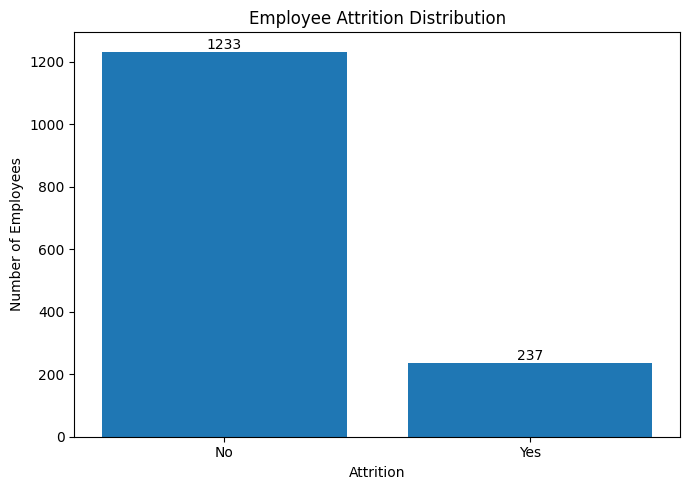

In [15]:
# Overall attrition chart
counts = data["Attrition"].value_counts().reindex(["No", "Yes"]).fillna(0)

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for x, y in zip(counts.index, counts.values):
    plt.text(x, y, f"{int(y)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 7. Business Question 1
### Which departments show higher observed attrition?

I compare the percentage of employees who left within each department. I also show the number of employees in each department because a rate from a small group should be read carefully.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
Department,,,,
Sales,446,92,20.63,False
Human Resources,63,12,19.05,False
Research & Development,961,133,13.84,False


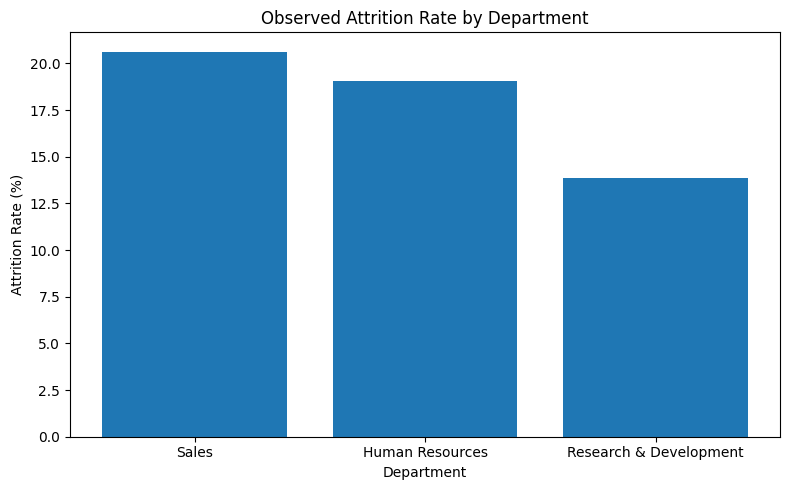

In [16]:
def attrition_rate_table(df, group_col):
    grouped = df.groupby(group_col, dropna=False, observed=True)
    result = grouped["Attrition"].agg(
        Employee_Count="size",
        Attrition_Count=lambda s: int((s == "Yes").sum())
    )
    result["Attrition_Rate_Percent"] = (result["Attrition_Count"] / result["Employee_Count"] * 100).round(2)
    result["Small_Group"] = result["Employee_Count"] < 30
    return result.sort_values("Attrition_Rate_Percent", ascending=False)

department_attrition = attrition_rate_table(data, "Department")
display(department_attrition)

plt.figure(figsize=(8,5))
plt.bar(department_attrition.index.astype(str), department_attrition["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 8. Business Question 2
### Which job roles show higher observed attrition?

Job roles can have different workloads, career paths and employee profiles. I use within-role attrition rates and group counts instead of looking only at the number of employees who left.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
JobRole,,,,
Sales Representative,83,33,39.76,False
Laboratory Technician,259,62,23.94,False
Human Resources,52,12,23.08,False
Sales Executive,326,57,17.48,False
Research Scientist,292,47,16.10,False
Manufacturing Director,145,10,6.90,False
Healthcare Representative,131,9,6.87,False
Manager,102,5,4.90,False
Research Director,80,2,2.50,False


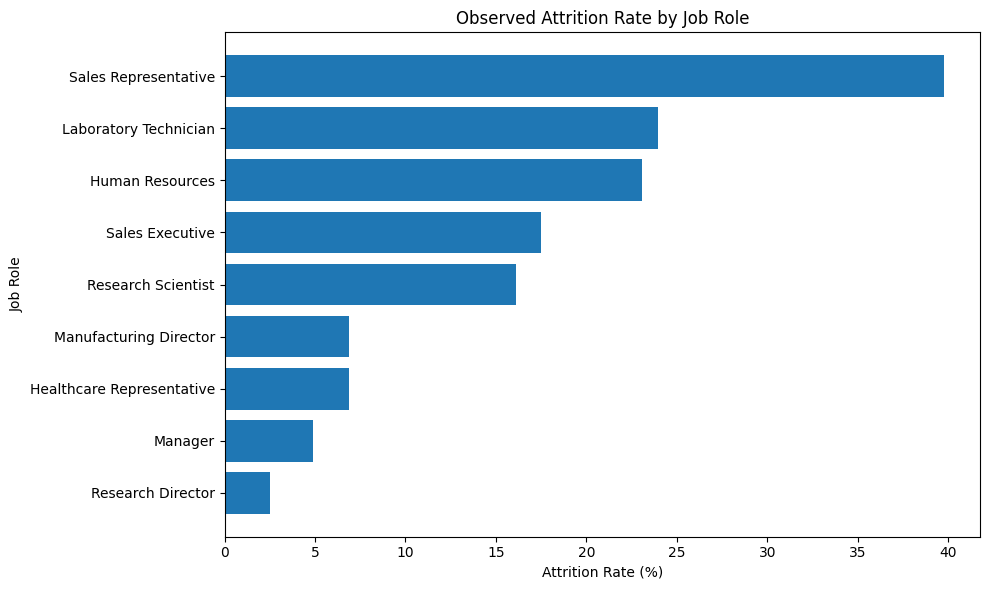

In [17]:
role_attrition = attrition_rate_table(data, "JobRole")
display(role_attrition)

role_plot = role_attrition.sort_values("Attrition_Rate_Percent")
plt.figure(figsize=(10,6))
plt.barh(role_plot.index.astype(str), role_plot["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()


## 9. Business Question 3
### Is overtime associated with higher observed attrition?

This is an association check. Even if the overtime group has a higher attrition rate, this result alone does not prove that overtime causes employees to leave.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
OverTime,,,,
Yes,416,127,30.53,False
No,1054,110,10.44,False


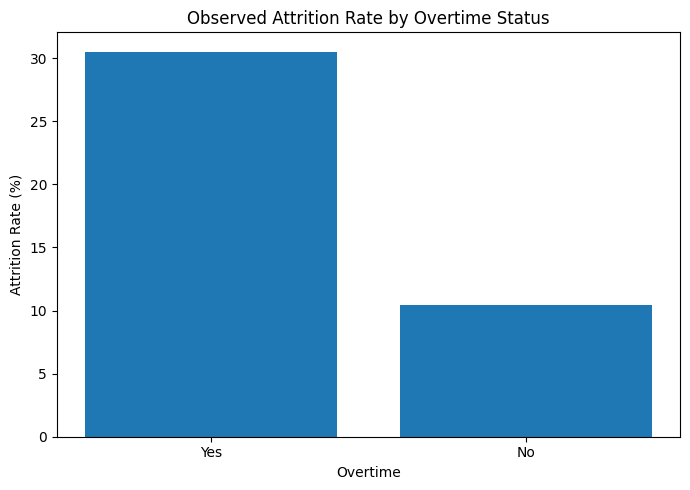

In [18]:
overtime_attrition = attrition_rate_table(data, "OverTime")
display(overtime_attrition)

plt.figure(figsize=(7,5))
plt.bar(overtime_attrition.index.astype(str), overtime_attrition["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 10. Business Question 4
### How does job satisfaction relate to observed attrition?

Job satisfaction is a rating scale. I compare the observed attrition rate at each level and avoid treating the rating number as a normal continuous measurement.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
JobSatisfaction,,,,
1,289,66,22.84,False
3,442,73,16.52,False
2,280,46,16.43,False
4,459,52,11.33,False


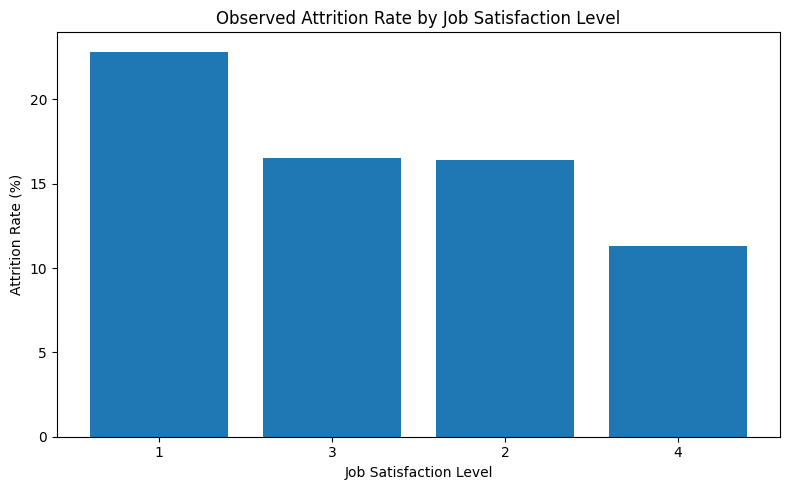

In [19]:
satisfaction_attrition = attrition_rate_table(data, "JobSatisfaction")
display(satisfaction_attrition)

plt.figure(figsize=(8,5))
plt.bar(satisfaction_attrition.index.astype(str), satisfaction_attrition["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Job Satisfaction Level")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 11. Business Question 5
### How does monthly income differ between employees who stayed and employees who left?

I use both mean and median because one average alone can hide the shape of the distribution. I also show a boxplot to make the difference easier to see.


,count,mean,median,std,min,max
Attrition,,,,,,
No,1233,6832.74,5204.0,4818.21,1051,19999
Yes,237,4787.09,3202.0,3640.21,1009,19859


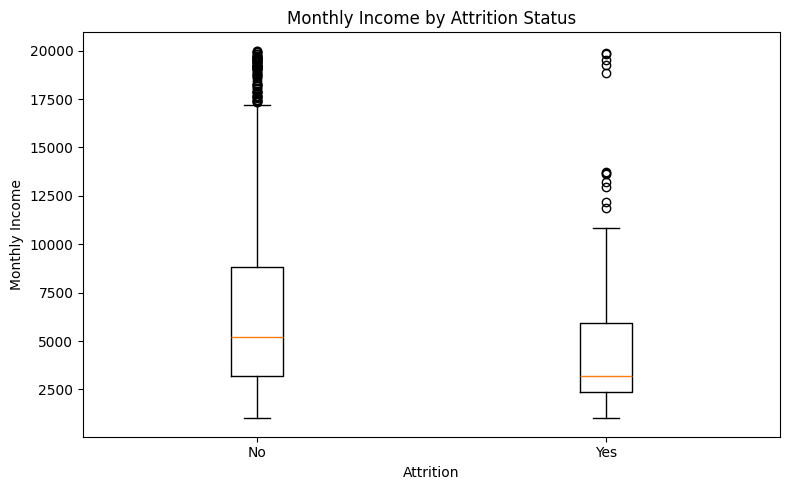

In [20]:
income_summary = (
    data.groupby("Attrition")["MonthlyIncome"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
display(income_summary)

# Boxplot of monthly income by attrition status
no_income = data.loc[data["Attrition"] == "No", "MonthlyIncome"]
yes_income = data.loc[data["Attrition"] == "Yes", "MonthlyIncome"]

plt.figure(figsize=(8,5))
plt.boxplot([no_income, yes_income], labels=["No", "Yes"], showfliers=True)
plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.tight_layout()
plt.show()

## 12. Business Question 6
### How does distance from home relate to observed attrition?

I use practical distance bands so the result is easier to compare. The bands are for interpretation only and do not change the original distance values.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
DistanceBand,,,,
21+,204,45,22.06,False
11-20,240,48,20.00,False
6-10,394,57,14.47,False
1-5,632,87,13.77,False


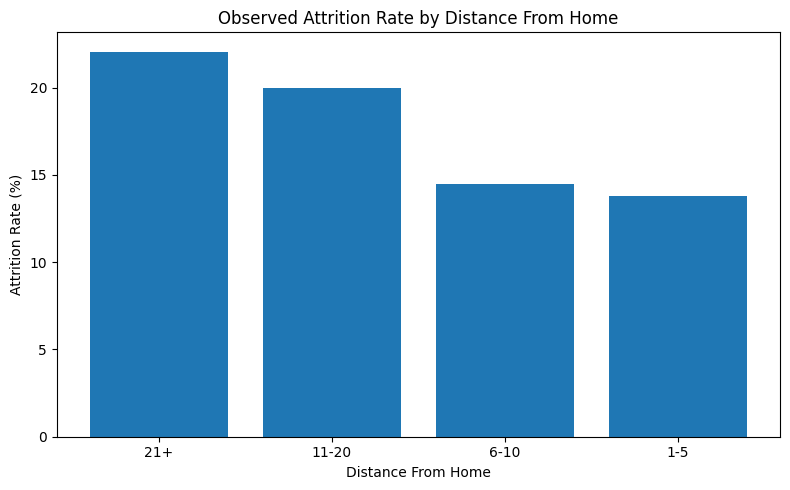

In [21]:
data["DistanceBand"] = pd.cut(
    data["DistanceFromHome"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["1-5", "6-10", "11-20", "21+"],
    include_lowest=True
)

distance_attrition = attrition_rate_table(data, "DistanceBand")
display(distance_attrition)

plt.figure(figsize=(8,5))
plt.bar(distance_attrition.index.astype(str), distance_attrition["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Distance From Home")
plt.xlabel("Distance From Home")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 13. Business Question 7
### How does tenure at the company relate to observed attrition?

I group years at the company into simple tenure bands. This helps me see whether early-tenure employees show a different observed attrition pattern from longer-tenure employees.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
TenureBand,,,,
0-1,215,75,34.88,False
2-3,255,47,18.43,False
4-5,306,40,13.07,False
6-10,448,55,12.28,False
11+,246,20,8.13,False


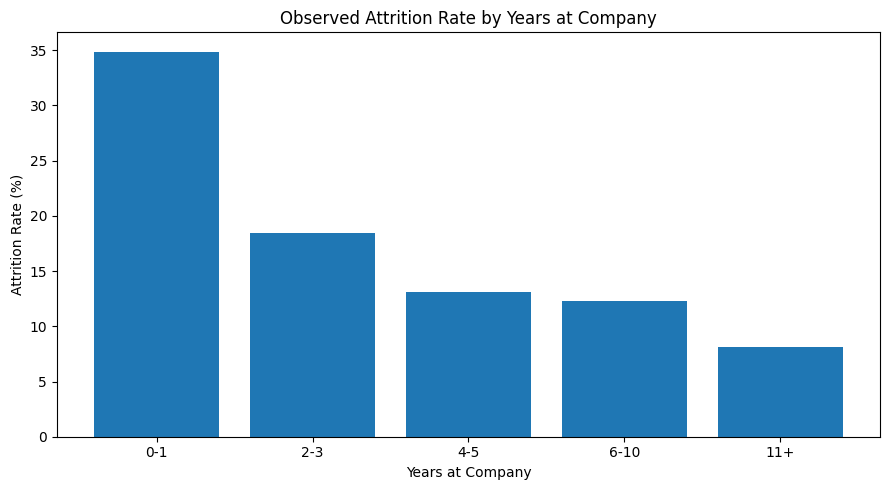

In [22]:
data["TenureBand"] = pd.cut(
    data["YearsAtCompany"],
    bins=[-1, 1, 3, 5, 10, np.inf],
    labels=["0-1", "2-3", "4-5", "6-10", "11+"]
)

tenure_attrition = attrition_rate_table(data, "TenureBand")
display(tenure_attrition)

plt.figure(figsize=(9,5))
plt.bar(tenure_attrition.index.astype(str), tenure_attrition["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 14. Business Question 8
### Which business travel category has higher observed attrition?

I again compare within-group attrition rates. Travel frequency may be linked with other work characteristics, so I treat this as a descriptive association rather than a direct reason for leaving.


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
BusinessTravel,,,,
Travel_Frequently,277,69,24.91,False
Travel_Rarely,1043,156,14.96,False
Non-Travel,150,12,8.00,False


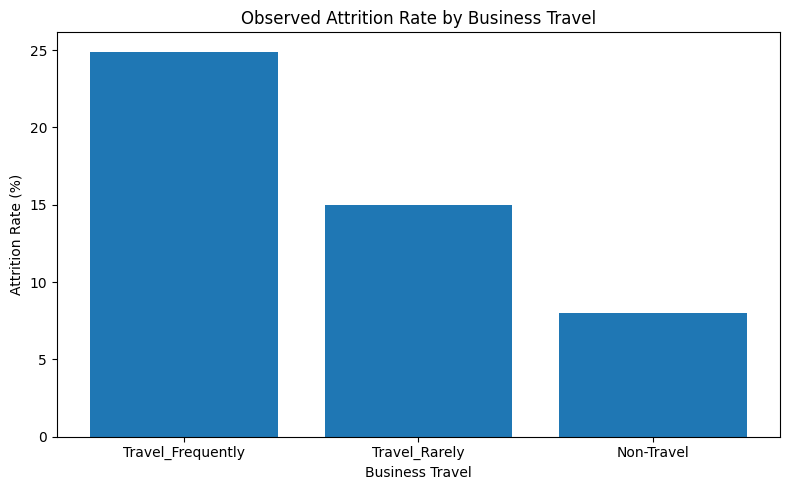

In [23]:
travel_attrition = attrition_rate_table(data, "BusinessTravel")
display(travel_attrition)

plt.figure(figsize=(8,5))
plt.bar(travel_attrition.index.astype(str), travel_attrition["Attrition_Rate_Percent"])
plt.title("Observed Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.show()


## 15. Additional EDA: employee profile and work-life balance

The main business questions above cover the most direct attrition factors. I also checked age groups and work-life balance to make the EDA more complete without making any causal claim.


In [24]:
# Age bands
age_data = data.copy()
age_data["AgeBand"] = pd.cut(
    age_data["Age"],
    bins=[17, 24, 34, 44, 54, np.inf],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"]
)

age_attrition = attrition_rate_table(age_data, "AgeBand")
print("Age band attrition:")
display(age_attrition)

# Work-life balance
worklife_attrition = attrition_rate_table(data, "WorkLifeBalance")
print("Work-life balance attrition:")
display(worklife_attrition)


Age band attrition:


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
AgeBand,,,,
18-24,97,38,39.18,False
25-34,554,112,20.22,False
55+,69,11,15.94,False
45-54,245,25,10.20,False
35-44,505,51,10.10,False


Work-life balance attrition:


,Employee_Count,Attrition_Count,Attrition_Rate_Percent,Small_Group
WorkLifeBalance,,,,
1,80,25,31.25,False
4,153,27,17.65,False
2,344,58,16.86,False
3,893,127,14.22,False


## 16. Univariate analysis

I looked at the distribution of important numeric variables. The aim is to understand the spread of the data before comparing groups.


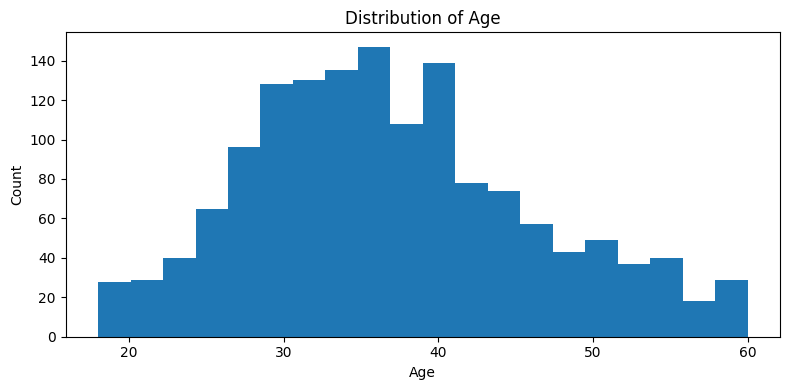

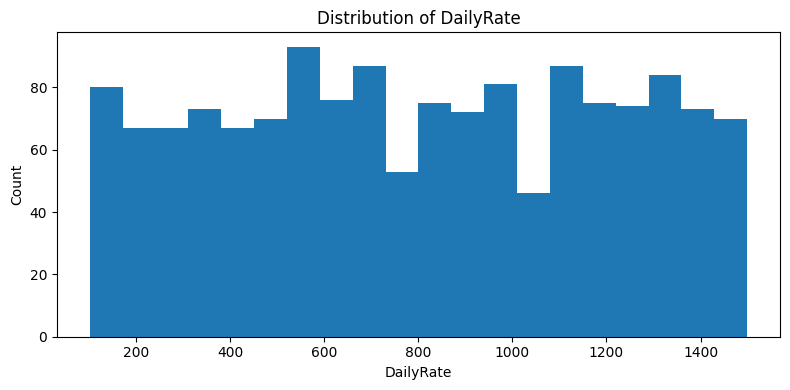

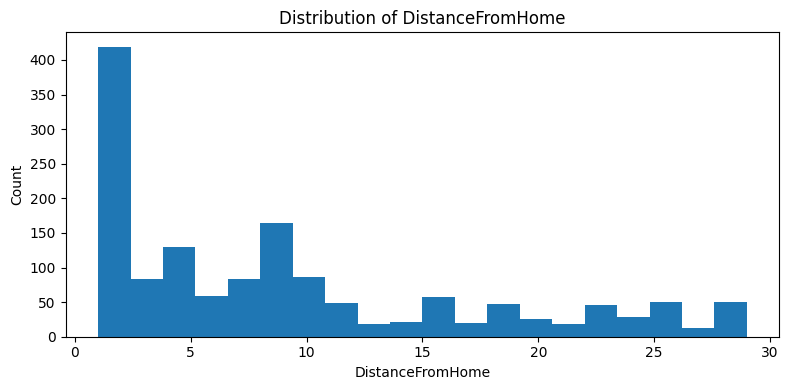

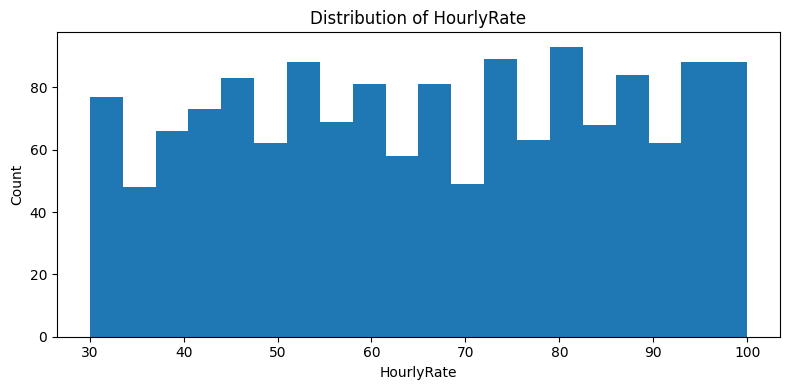

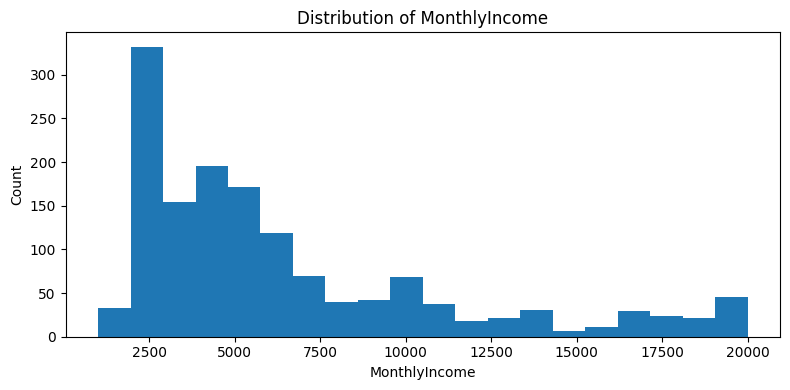

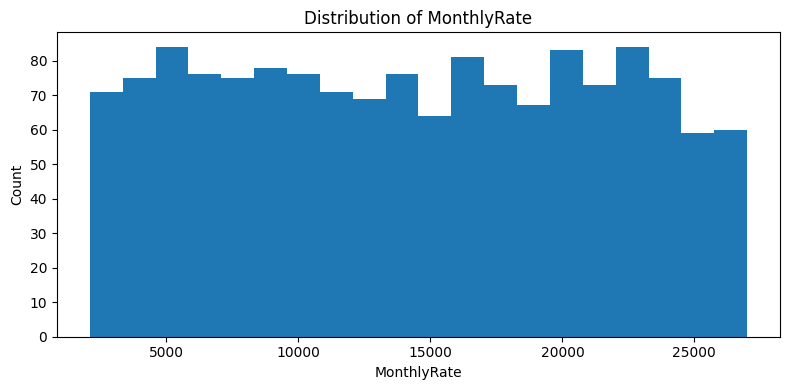

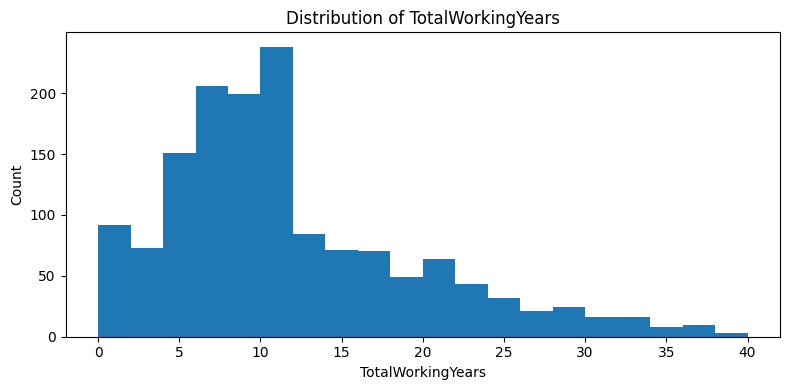

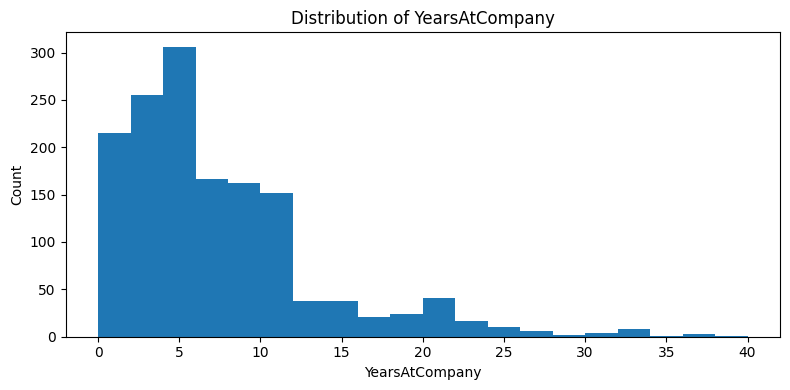

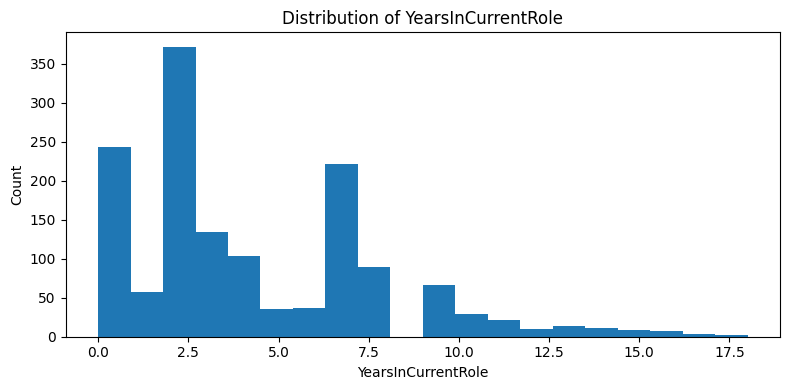

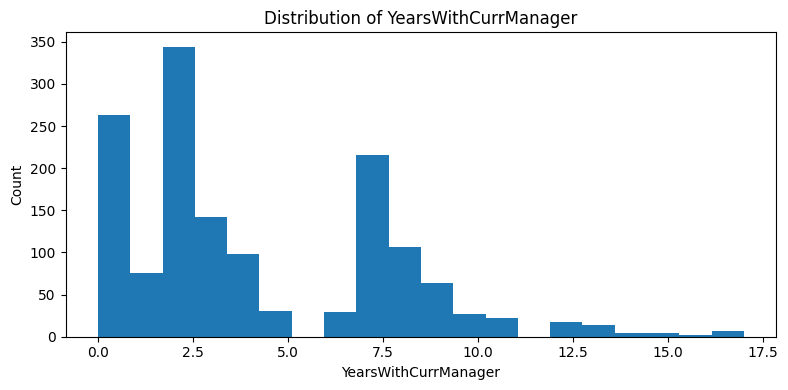

In [25]:
numeric_cols = [
    "Age", "DailyRate", "DistanceFromHome", "HourlyRate",
    "MonthlyIncome", "MonthlyRate", "TotalWorkingYears",
    "YearsAtCompany", "YearsInCurrentRole", "YearsWithCurrManager"
]
numeric_cols = [c for c in numeric_cols if c in data.columns]

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(data[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 17. Correlation analysis

I used Pearson correlation for selected numeric variables as an exploratory check. Correlation tells me whether two numeric variables move together linearly in this sample. It does **not** prove that one variable causes another.


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
Age,1.00,0.01,-0.00,0.02,0.50,0.03,0.68,0.31,0.21,0.20
DailyRate,0.01,1.00,-0.00,0.02,0.01,-0.03,0.01,-0.03,0.01,-0.03
DistanceFromHome,-0.00,-0.00,1.00,0.03,-0.02,0.03,0.00,0.01,0.02,0.01
HourlyRate,0.02,0.02,0.03,1.00,-0.02,-0.02,-0.00,-0.02,-0.02,-0.02
MonthlyIncome,0.50,0.01,-0.02,-0.02,1.00,0.03,0.77,0.51,0.36,0.34
MonthlyRate,0.03,-0.03,0.03,-0.02,0.03,1.00,0.03,-0.02,-0.01,-0.04
TotalWorkingYears,0.68,0.01,0.00,-0.00,0.77,0.03,1.00,0.63,0.46,0.46
YearsAtCompany,0.31,-0.03,0.01,-0.02,0.51,-0.02,0.63,1.00,0.76,0.77
YearsInCurrentRole,0.21,0.01,0.02,-0.02,0.36,-0.01,0.46,0.76,1.00,0.71
YearsWithCurrManager,0.20,-0.03,0.01,-0.02,0.34,-0.04,0.46,0.77,0.71,1.00


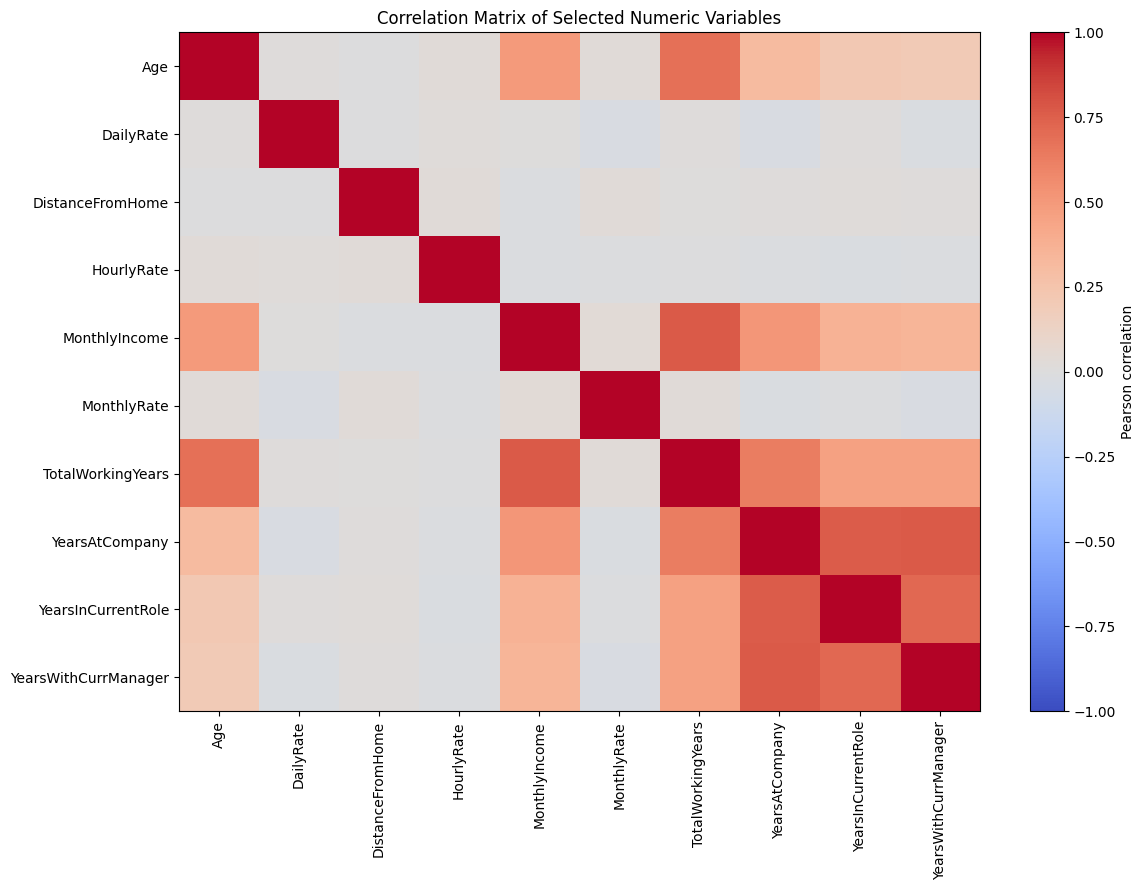

Strongest absolute numeric correlations:


Pearson_Correlation
MonthlyIncome      TotalWorkingYears                0.772893
YearsAtCompany     YearsWithCurrManager             0.769212
                   YearsInCurrentRole               0.758754
YearsInCurrentRole YearsWithCurrManager             0.714365
Age                TotalWorkingYears                0.680381
TotalWorkingYears  YearsAtCompany                   0.628133
MonthlyIncome      YearsAtCompany                   0.514285
Age                MonthlyIncome                    0.497855
TotalWorkingYears  YearsInCurrentRole               0.460365
                   YearsWithCurrManager             0.459188

In [26]:
corr_cols = numeric_cols
corr = data[corr_cols].corr()

display(corr.round(2))

plt.figure(figsize=(12,9))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix of Selected Numeric Variables")
plt.tight_layout()
plt.show()

# Show the strongest absolute correlations without the diagonal
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strongest_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index).head(10)

print("Strongest absolute numeric correlations:")
display(strongest_pairs.rename("Pearson_Correlation").to_frame())

## 18. Multivariate analysis

Looking at one factor at a time can miss useful context. Here I compare **overtime and job satisfaction together while directly measuring attrition**. I also show employee counts so the rates are not read without context.

This is still descriptive EDA. It does not prove that either factor causes attrition.


,OverTime,JobSatisfaction,Employee_Count,Attrition_Count,Observed_Attrition_Rate_Percent,Small_Group
5,Yes,2,69,26,37.68,False
4,Yes,1,84,30,35.71,False
6,Yes,3,121,41,33.88,False
7,Yes,4,142,30,21.13,False
0,No,1,205,36,17.56,False
2,No,3,321,32,9.97,False
1,No,2,211,20,9.48,False
3,No,4,317,22,6.94,False


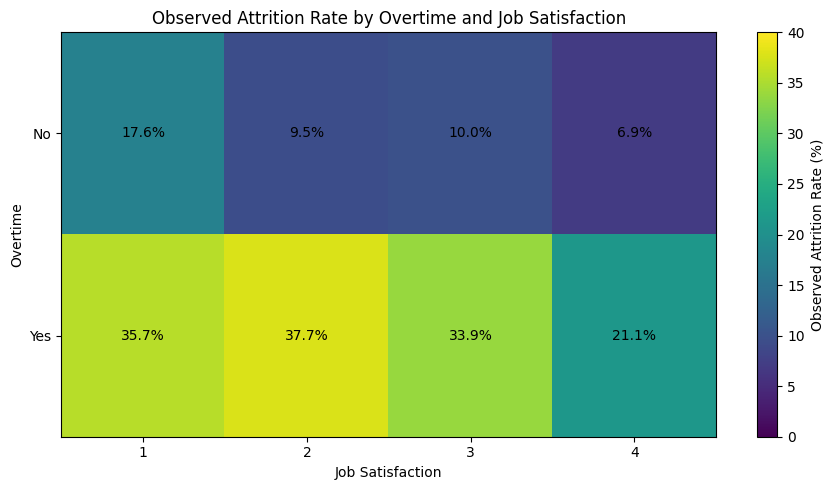

Small groups are flagged for careful interpretation; no rows are removed because of group size.


In [27]:
# Attrition rate by overtime and job satisfaction together
multivariate_attrition = (
    data.assign(Attrition_Flag=(data["Attrition"] == "Yes").astype(int))
    .groupby(["OverTime", "JobSatisfaction"], observed=True)
    .agg(
        Employee_Count=("Attrition_Flag", "size"),
        Attrition_Count=("Attrition_Flag", "sum"),
        Observed_Attrition_Rate_Percent=("Attrition_Flag", "mean")
    )
    .reset_index()
)
multivariate_attrition["Observed_Attrition_Rate_Percent"] = (
    multivariate_attrition["Observed_Attrition_Rate_Percent"] * 100
).round(2)
multivariate_attrition["Small_Group"] = multivariate_attrition["Employee_Count"] < 30

display(multivariate_attrition.sort_values("Observed_Attrition_Rate_Percent", ascending=False))

pivot_attrition_multi = multivariate_attrition.pivot(
    index="OverTime", columns="JobSatisfaction", values="Observed_Attrition_Rate_Percent"
)

plt.figure(figsize=(9,5))
plt.imshow(pivot_attrition_multi, aspect="auto", vmin=0, vmax=max(40, float(np.nanmax(pivot_attrition_multi.values))))
plt.colorbar(label="Observed Attrition Rate (%)")
plt.xticks(range(len(pivot_attrition_multi.columns)), pivot_attrition_multi.columns)
plt.yticks(range(len(pivot_attrition_multi.index)), pivot_attrition_multi.index)

for i in range(pivot_attrition_multi.shape[0]):
    for j in range(pivot_attrition_multi.shape[1]):
        value = pivot_attrition_multi.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.1f}%", ha="center", va="center")

plt.title("Observed Attrition Rate by Overtime and Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Overtime")
plt.tight_layout()
plt.show()

print("Small groups are flagged for careful interpretation; no rows are removed because of group size.")


## 19. Statistical validation of the main EDA patterns

To make the analysis stronger, I added simple statistical checks.

For categorical variables, I use the **Chi-square test of independence** and report **Cramer's V** as an effect-size measure. For numeric variables, I use the **Mann-Whitney U test** and report a rank-biserial effect size.

Because several tests are performed, I also apply a **Benjamini-Hochberg false discovery rate (FDR) adjustment** to the p-values. This reduces the chance of treating a result as important only because many tests were tried.

I use `p < 0.05` only as an exploratory reference. A small p-value does not prove causation, and a statistically detectable pattern is not automatically a practically important business issue. That is why I read the p-value together with effect size, group size and the business context.


In [28]:
# Chi-square tests for categorical variables
categorical_test_cols = [
    "Department", "JobRole", "OverTime", "BusinessTravel",
    "JobSatisfaction", "DistanceBand", "TenureBand"
]

chi_rows = []
for col in categorical_test_cols:
    table = pd.crosstab(data[col], data["Attrition"])
    if table.shape[0] >= 2 and table.shape[1] >= 2:
        chi2, p_value, dof, expected = chi2_contingency(table)
        n = table.to_numpy().sum()
        min_dim = min(table.shape[0] - 1, table.shape[1] - 1)
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
        smallest_group = int(data[col].value_counts(dropna=False).min())
        chi_rows.append([col, float(chi2), float(p_value), float(cramers_v), smallest_group])

chi_square_results = pd.DataFrame(
    chi_rows,
    columns=["Variable", "Chi_Square", "P_Value", "Cramers_V", "Smallest_Group_Count"]
)

# Benjamini-Hochberg adjustment across the categorical tests
p = chi_square_results["P_Value"].to_numpy()
order = np.argsort(p)
adj = np.empty(len(p), dtype=float)
if len(p) > 0:
    ranked = np.arange(1, len(p) + 1)
    ordered_adj = p[order] * len(p) / ranked
    ordered_adj = np.minimum.accumulate(ordered_adj[::-1])[::-1]
    adj[order] = np.minimum(ordered_adj, 1.0)
    chi_square_results["FDR_Adjusted_P_Value"] = adj
else:
    chi_square_results["FDR_Adjusted_P_Value"] = []

def cramers_v_label(v):
    if pd.isna(v):
        return "Not available"
    if v < 0.10:
        return "Very small association"
    if v < 0.30:
        return "Small association"
    if v < 0.50:
        return "Moderate association"
    return "Large association"

chi_square_results["Effect_Size_Interpretation"] = chi_square_results["Cramers_V"].apply(cramers_v_label)
chi_square_results["Exploratory_Result"] = np.where(
    chi_square_results["FDR_Adjusted_P_Value"] < 0.05,
    "Association remains supported after FDR adjustment",
    "No clear association after FDR adjustment"
)

chi_square_results[["Chi_Square", "P_Value", "FDR_Adjusted_P_Value", "Cramers_V"]] = chi_square_results[["Chi_Square", "P_Value", "FDR_Adjusted_P_Value", "Cramers_V"]].round(4)
display(chi_square_results)
print("FDR adjustment reduces the risk of over-interpreting a result only because several tests were performed.")


,Variable,Chi_Square,P_Value,Cramers_V,Smallest_Group_Count,FDR_Adjusted_P_Value,Effect_Size_Interpretation,Exploratory_Result
0,Department,10.7960,0.0045,0.0857,63,0.0053,Very small association,Association remains supported after FDR adjust...
1,JobRole,86.1903,0.0000,0.2421,52,0.0000,Small association,Association remains supported after FDR adjust...
2,OverTime,87.5643,0.0000,0.2441,416,0.0000,Small association,Association remains supported after FDR adjust...
3,BusinessTravel,24.1824,0.0000,0.1283,150,0.0000,Small association,Association remains supported after FDR adjust...
4,JobSatisfaction,17.5051,0.0006,0.1091,280,0.0008,Small association,Association remains supported after FDR adjust...
5,DistanceBand,11.3785,0.0098,0.0880,204,0.0098,Very small association,Association remains supported after FDR adjust...
6,TenureBand,75.5916,0.0000,0.2268,215,0.0000,Small association,Association remains supported after FDR adjust...


FDR adjustment reduces the risk of over-interpreting a result only because several tests were performed.


In [29]:
# Mann-Whitney U tests for numeric variables
numeric_test_cols = [
    "Age", "MonthlyIncome", "DistanceFromHome",
    "YearsAtCompany", "TotalWorkingYears"
]

mann_rows = []
for col in numeric_test_cols:
    stayed = data.loc[data["Attrition"] == "No", col].dropna()
    left = data.loc[data["Attrition"] == "Yes", col].dropna()
    if len(stayed) > 0 and len(left) > 0:
        u_stat, p_value = mannwhitneyu(left, stayed, alternative="two-sided")
        # Rank-biserial correlation: -1 to +1, describing direction and strength of the group difference
        rank_biserial = (2 * float(u_stat) / (len(left) * len(stayed))) - 1
        mann_rows.append([
            col,
            len(stayed),
            len(left),
            float(stayed.median()),
            float(left.median()),
            float(left.median() - stayed.median()),
            float(p_value),
            float(rank_biserial)
        ])

mann_whitney_results = pd.DataFrame(
    mann_rows,
    columns=["Variable", "Stayed_N", "Left_N", "Stayed_Median", "Left_Median", "Median_Difference", "P_Value", "Rank_Biserial"]
)

# Benjamini-Hochberg adjustment across the numeric tests
p = mann_whitney_results["P_Value"].to_numpy()
order = np.argsort(p)
adj = np.empty(len(p), dtype=float)
if len(p) > 0:
    ranked = np.arange(1, len(p) + 1)
    ordered_adj = p[order] * len(p) / ranked
    ordered_adj = np.minimum.accumulate(ordered_adj[::-1])[::-1]
    adj[order] = np.minimum(ordered_adj, 1.0)
    mann_whitney_results["FDR_Adjusted_P_Value"] = adj
else:
    mann_whitney_results["FDR_Adjusted_P_Value"] = []

def rank_biserial_label(v):
    av = abs(v)
    if av < 0.10:
        return "Very small difference"
    if av < 0.30:
        return "Small difference"
    if av < 0.50:
        return "Moderate difference"
    return "Large difference"

mann_whitney_results["Effect_Size_Interpretation"] = mann_whitney_results["Rank_Biserial"].apply(rank_biserial_label)
mann_whitney_results["Exploratory_Result"] = np.where(
    mann_whitney_results["FDR_Adjusted_P_Value"] < 0.05,
    "Evidence of distribution difference after FDR adjustment",
    "No clear distribution difference after FDR adjustment"
)

mann_whitney_results[["Stayed_Median", "Left_Median", "Median_Difference", "P_Value", "Rank_Biserial", "FDR_Adjusted_P_Value"]] = mann_whitney_results[["Stayed_Median", "Left_Median", "Median_Difference", "P_Value", "Rank_Biserial", "FDR_Adjusted_P_Value"]].round(4)
display(mann_whitney_results)
print("Effect size is included so I do not rely on p-values alone.")


,Variable,Stayed_N,Left_N,Stayed_Median,Left_Median,Median_Difference,P_Value,Rank_Biserial,FDR_Adjusted_P_Value,Effect_Size_Interpretation,Exploratory_Result
0,Age,1233,237,36.0,32.0,-4.0,0.0000,-0.2686,0.0000,Small difference,Evidence of distribution difference after FDR ...
1,MonthlyIncome,1233,237,5204.0,3202.0,-2002.0,0.0000,-0.3113,0.0000,Moderate difference,Evidence of distribution difference after FDR ...
2,DistanceFromHome,1233,237,7.0,9.0,2.0,0.0024,0.1240,0.0024,Small difference,Evidence of distribution difference after FDR ...
3,YearsAtCompany,1233,237,6.0,3.0,-3.0,0.0000,-0.2979,0.0000,Small difference,Evidence of distribution difference after FDR ...
4,TotalWorkingYears,1233,237,10.0,7.0,-3.0,0.0000,-0.3117,0.0000,Moderate difference,Evidence of distribution difference after FDR ...


Effect size is included so I do not rely on p-values alone.


## 20. Group-size safeguard

A high percentage from a very small group can look impressive even when the actual number of employees is low. For that reason, I flag groups with fewer than 30 employees.

This does **not** mean those employees should be ignored or removed. It only means the percentage should be interpreted carefully and checked with more data before making an operational decision.


In [30]:
# Check group sizes before using rate comparisons as business priorities
small_group_sources = {
    "Department": data["Department"],
    "JobRole": data["JobRole"],
    "OverTime": data["OverTime"],
    "BusinessTravel": data["BusinessTravel"],
    "DistanceBand": data["DistanceBand"],
    "TenureBand": data["TenureBand"]
}

small_group_rows = []
for name, series in small_group_sources.items():
    counts = series.value_counts(dropna=False)
    for group, count in counts.items():
        small_group_rows.append([name, group, int(count), int(count) < 30])

small_groups = pd.DataFrame(
    small_group_rows,
    columns=["Dimension", "Group", "Employee_Count", "Small_Group"]
)

print("Groups with fewer than 30 employees:")
display(
    small_groups[small_groups["Small_Group"]]
    .sort_values("Employee_Count")
)


Groups with fewer than 30 employees:


,Dimension,Group,Employee_Count,Small_Group


## 21. Evidence summary

The table below keeps the final comparison simple: group name, employee count, attrition count and observed attrition rate. This helps me avoid choosing a group using percentage alone.


In [31]:
summary_sources = {
    "Department": department_attrition,
    "JobRole": role_attrition,
    "OverTime": overtime_attrition,
    "BusinessTravel": travel_attrition,
    "DistanceBand": distance_attrition,
    "TenureBand": tenure_attrition
}

summary_rows = []
for dimension, frame in summary_sources.items():
    top = frame.iloc[0]
    group_name = frame.index[0]
    summary_rows.append([
        dimension,
        str(group_name),
        int(top["Employee_Count"]),
        int(top["Attrition_Count"]),
        float(top["Attrition_Rate_Percent"]),
        bool(top["Small_Group"])
    ])

final_evidence = pd.DataFrame(
    summary_rows,
    columns=["Dimension", "Highest_Rate_Group", "Employee_Count", "Attrition_Count", "Observed_Attrition_Rate_Percent", "Small_Group"]
)

display(final_evidence)


,Dimension,Highest_Rate_Group,Employee_Count,Attrition_Count,Observed_Attrition_Rate_Percent,Small_Group
0,Department,Sales,446,92,20.63,False
1,JobRole,Sales Representative,83,33,39.76,False
2,OverTime,Yes,416,127,30.53,False
3,BusinessTravel,Travel_Frequently,277,69,24.91,False
4,DistanceBand,21+,204,45,22.06,False
5,TenureBand,0-1,215,75,34.88,False


In [32]:
# Add a simple, transparent priority flag for the final evidence table
priority = final_evidence.copy()
priority["Overall_Rate_Percent"] = (data["Attrition"] == "Yes").mean() * 100
priority["Rate_Difference_From_Overall"] = (
    priority["Observed_Attrition_Rate_Percent"] - priority["Overall_Rate_Percent"]
).round(2)
priority["Investigation_Priority"] = np.where(
    (~priority["Small_Group"]) & (priority["Rate_Difference_From_Overall"] >= 5),
    "Higher priority",
    "Review with context"
)

display(priority[[
    "Dimension", "Highest_Rate_Group", "Employee_Count", "Attrition_Count",
    "Observed_Attrition_Rate_Percent", "Rate_Difference_From_Overall", "Investigation_Priority"
]])
print("Priority rule: at least 5 percentage points above the overall observed rate and not a small group.")


,Dimension,Highest_Rate_Group,Employee_Count,Attrition_Count,Observed_Attrition_Rate_Percent,Rate_Difference_From_Overall,Investigation_Priority
0,Department,Sales,446,92,20.63,4.51,Review with context
1,JobRole,Sales Representative,83,33,39.76,23.64,Higher priority
2,OverTime,Yes,416,127,30.53,14.41,Higher priority
3,BusinessTravel,Travel_Frequently,277,69,24.91,8.79,Higher priority
4,DistanceBand,21+,204,45,22.06,5.94,Higher priority
5,TenureBand,0-1,215,75,34.88,18.76,Higher priority


Priority rule: at least 5 percentage points above the overall observed rate and not a small group.


## 22. Key findings

The exact values are generated by the code so I do not have to manually copy percentages into the report. The main reading rule is:

**observed attrition rate + group size + statistical evidence + effect size**

A group becomes an investigation priority only when the rate is meaningfully high and the result is not based only on a very small group. Statistical evidence is treated as supporting evidence, not as proof of causation.

The final evidence table is therefore a practical summary of **where to look next**, not a list of proven causes.


In [33]:
# Generate a compact, data-driven findings summary
overall_rate = float(
    (data["Attrition"] == "Yes").mean() * 100
)

print(f"Overall observed attrition in the dataset: {overall_rate:.2f}%")
print()

for _, row in final_evidence.iterrows():
    caution = "Small group: interpret carefully." if row["Small_Group"] else "Group size is not below the 30-record flag."
    print(
        f"{row['Dimension']}: {row['Highest_Rate_Group']} has the highest observed rate "
        f"({row['Observed_Attrition_Rate_Percent']:.2f}%) among the groups checked "
        f"with {row['Employee_Count']} employees. {caution}"
    )

# Simple income comparison for the final summary
income_no = float(data.loc[data["Attrition"] == "No", "MonthlyIncome"].median())
income_yes = float(data.loc[data["Attrition"] == "Yes", "MonthlyIncome"].median())
print(f"Monthly income median - stayed: {income_no:.2f}; left: {income_yes:.2f}.")


Overall observed attrition in the dataset: 16.12%

Department: Sales has the highest observed rate (20.63%) among the groups checked with 446 employees. Group size is not below the 30-record flag.
JobRole: Sales Representative has the highest observed rate (39.76%) among the groups checked with 83 employees. Group size is not below the 30-record flag.
OverTime: Yes has the highest observed rate (30.53%) among the groups checked with 416 employees. Group size is not below the 30-record flag.
BusinessTravel: Travel_Frequently has the highest observed rate (24.91%) among the groups checked with 277 employees. Group size is not below the 30-record flag.
DistanceBand: 21+ has the highest observed rate (22.06%) among the groups checked with 204 employees. Group size is not below the 30-record flag.
TenureBand: 0-1 has the highest observed rate (34.88%) among the groups checked with 215 employees. Group size is not below the 30-record flag.
Monthly income median - stayed: 5204.00; left: 3202.

## 23. Business recommendations

Based on the evidence in this notebook, I would treat the following as **next-step investigation priorities** rather than direct policy decisions:

1. **Review overtime and workload.** Compare teams with high overtime-related attrition with workload, staffing and manager information.
2. **Look closely at high-attrition job roles.** Use role-level employee feedback before deciding on any retention action.
3. **Pay attention to early-tenure employees.** Check onboarding, training, manager support and the first-year employee experience.
4. **Review travel and commute-related patterns.** Check whether frequent travel or longer distance is linked with other work conditions.
5. **Study satisfaction and work-life balance together with other factors.** A single rating should not be used alone for an HR decision.
6. **Use current HR data to validate the patterns.** The Kaggle dataset is useful for analysis practice, but real decisions need current internal information.
7. **Track the metric after an intervention.** If an organization takes an action, compare attrition rates over time to see whether the result actually improves.


## 24. What I would not conclude

I would **not** write statements such as “overtime causes attrition” or “employees leave because of low income” from this notebook.

The data is observational. The analysis shows patterns and associations in this sample. Other variables can be related to the same result, so stronger claims would need better study design and additional real-world evidence.


## 25. Limitations

There are some important limits to this project:

- The dataset is fictional and is useful mainly for demonstrating an analytics workflow.
- The analysis is observational, so it does not prove cause and effect.
- The results should not be treated as representative of every organization.
- Some satisfaction and rating fields are coded levels, so their numbers should not be interpreted like normal continuous measurements.
- The dataset does not give the full reason why each employee left.
- There is no suitable date field for a proper time-series attrition trend.
- A few small groups may have unstable percentages, which is why the notebook flags them.
- Statistical p-values can support an association check, but they do not prove business importance or causality.
- Real HR data, employee feedback and repeated measurements would be needed before using the findings for actual policy decisions.


## 26. Validation and reproducibility

This section is the final quality gate for the notebook. It checks the source shape, required fields, missing values, duplicates, identifier uniqueness, derived columns, important value ranges and completion of the statistical checks.

The notebook is intended to be reproducible by running the cells from top to bottom in Google Colab.


In [34]:
# Reproducibility summary
print("Dataset file:", os.path.basename(csv_path))
print("Kaggle dataset identifier:", KAGGLE_DATASET)
print("Raw rows:", len(df))
print("Raw columns:", len(df.columns))
print("Analytical rows:", len(data))
print("Analytical columns:", len(data.columns))
print("Random state: None. This is descriptive EDA, not a model training task.")
print("Execution order: top to bottom.")
print("Final checks: completed in the next cell.")


Dataset file: WA_Fn-UseC_-HR-Employee-Attrition.csv
Kaggle dataset identifier: pavansubhasht/ibm-hr-analytics-attrition-dataset
Raw rows: 1470
Raw columns: 35
Analytical rows: 1470
Analytical columns: 34
Random state: None. This is descriptive EDA, not a model training task.
Execution order: top to bottom.
Final checks: completed in the next cell.


In [35]:
# Final automated quality checklist
required_business_columns = [
    "Department", "JobRole", "OverTime", "JobSatisfaction",
    "MonthlyIncome", "DistanceFromHome", "YearsAtCompany", "BusinessTravel",
    "DistanceBand", "TenureBand"
]

checks = {
    "Correct raw dataset shape": tuple(df.shape) == EXPECTED_SHAPE,
    "Rows present": len(data) > 0,
    "Columns present": len(data.columns) > 0,
    "Complete data dictionary": len(data_dictionary) == len(df.columns),
    "No raw missing values": int(df.isna().sum().sum()) == 0,
    "No cleaned missing values": int(data.isna().sum().sum()) == 0,
    "No raw duplicate rows": int(df.duplicated().sum()) == 0,
    "No cleaned duplicate rows": int(data.duplicated().sum()) == 0,
    "EmployeeNumber exists": "EmployeeNumber" in data.columns,
    "EmployeeNumber remains unique": bool(data["EmployeeNumber"].is_unique),
    "Attrition column exists": "Attrition" in data.columns,
    "Attrition has expected categories": set(data["Attrition"].dropna().unique()).issubset({"Yes", "No"}),
    "Required business columns exist": all(c in data.columns for c in required_business_columns),
    "Derived distance band has no missing values": int(data["DistanceBand"].isna().sum()) == 0,
    "Derived tenure band has no missing values": int(data["TenureBand"].isna().sum()) == 0,
    "Age values are non-negative": bool((data["Age"] >= 0).all()),
    "Monthly income is non-negative": bool((data["MonthlyIncome"] >= 0).all()),
    "Years at company are non-negative": bool((data["YearsAtCompany"] >= 0).all()),
    "Logical role tenure check passed": logical_checks["YearsInCurrentRole <= YearsAtCompany"],
    "Logical manager tenure check passed": logical_checks["YearsWithCurrManager <= YearsAtCompany"],
    "Logical company tenure check passed": logical_checks["YearsAtCompany <= TotalWorkingYears"],
    "Chi-square checks completed": len(chi_square_results) >= 1,
    "Chi-square FDR correction completed": "FDR_Adjusted_P_Value" in chi_square_results.columns,
    "Chi-square effect interpretation completed": "Effect_Size_Interpretation" in chi_square_results.columns,
    "Mann-Whitney checks completed": len(mann_whitney_results) >= 1,
    "Mann-Whitney FDR correction completed": "FDR_Adjusted_P_Value" in mann_whitney_results.columns,
    "Mann-Whitney effect size completed": "Rank_Biserial" in mann_whitney_results.columns,
    "Multivariate attrition table completed": len(multivariate_attrition) > 0,
    "Priority evidence table completed": "Investigation_Priority" in priority.columns,
    "Final evidence table completed": len(final_evidence) == len(summary_sources)
}

validation_df = pd.DataFrame(
    [{"Check": k, "Passed": bool(v)} for k, v in checks.items()]
)

display(validation_df)

if validation_df["Passed"].all():
    print("PASS: All final validation checks passed.")
else:
    failed = validation_df.loc[~validation_df["Passed"], "Check"].tolist()
    print("REVIEW REQUIRED. Failed checks:")
    for item in failed:
        print("-", item)


,Check,Passed
0,Correct raw dataset shape,True
1,Rows present,True
2,Columns present,True
3,Complete data dictionary,True
4,No raw missing values,True
5,No cleaned missing values,True
6,No raw duplicate rows,True
7,No cleaned duplicate rows,True
8,EmployeeNumber exists,True
9,EmployeeNumber remains unique,True


PASS: All final validation checks passed.


## 28. Rubric coverage map

I used the Arrowstack evaluation areas while building this notebook. This table shows where the evidence can be found.

| Arrowstack area | Evidence in this notebook |
|---|---|
| Requirements & domain understanding | Business problem, stakeholder, measurable success criteria and business questions |
| Technical / professional execution | Python workflow, cleaning, EDA, visualizations, direct attrition-linked multivariate analysis and statistical checks |
| Quality, accuracy & validation | Missing values, duplicates, ID check, ranges, logical consistency checks, outlier review, group-size safeguard, FDR correction and final automated QA |
| Problem-solving & independence | Traceable cleaning decisions, rate-versus-count reasoning, effect-size reasoning and cautious interpretation |
| Documentation & reproducibility | Roadmap, complete data dictionary, reproducibility summary and final validation |
| Presentation & communication | Clear section structure, evidence tables, charts, conclusion and demo talking points |
| Creativity / improvement thinking | Dynamic dictionary, small-group safeguard, outlier review, multivariate attrition analysis, effect sizes and FDR correction |

This map is for review convenience. The actual evidence is in the code and outputs of the notebook.


## 29. Simple demo / viva explanation

### 60-90 second explanation

> I completed Task 1 by performing a complete exploratory data analysis on the IBM HR Analytics Employee Attrition dataset from Kaggle. I first checked the dataset structure, data types, missing values, duplicates, employee ID uniqueness, constant columns and basic numeric ranges. Then I created a clean copy for analysis and kept unusual values for review instead of removing them blindly.
>
> After that, I studied attrition by department, job role, overtime, job satisfaction, income, distance from home, tenure and business travel. I used both counts and within-group attrition rates because a percentage by itself can be misleading. I also added a small-group check so that a high percentage in a very small group is not treated as equally strong evidence.
>
> I used correlation, a simple multivariate view, Chi-square tests and Mann-Whitney tests to add more support to the EDA. My recommendations are investigation priorities, not causal conclusions. The final validation cell checks the important parts again so the notebook can be rerun in Colab before submission.

### Questions I should be ready for

**Why did you not remove all outliers?**  
Because an unusual employee value is not automatically an incorrect value. I reported the IQR outliers first and avoided deleting valid records without evidence.

**Why do you use attrition rate instead of only attrition count?**  
Because groups can have very different sizes. Rate makes the comparison fairer, while the group count tells me how much evidence sits behind the percentage.

**Does overtime cause attrition?**  
No. This notebook only shows an observed association in an observational dataset. More study would be needed to make a causal claim.

**Why add statistical tests to an EDA notebook?**  
They give an extra check on whether the sample shows evidence of an association or distribution difference. They do not prove business importance or causality.


## 30. Final project review

### What this notebook demonstrates

- Correct Kaggle dataset loading
- Complete source-column data dictionary
- Data-quality checks and traceable cleaning
- Target-variable analysis
- Eight main business questions
- Additional employee-profile checks
- Group-wise attrition rates with group-size caution
- Distribution and multivariate analysis
- Correlation analysis with correct interpretation
- Chi-square and Mann-Whitney validation
- Evidence-based findings
- Practical recommendations
- Clear limitations and responsible interpretation
- Final automated validation
- Reproducible Google Colab workflow
- Logical data consistency checks
- FDR-adjusted statistical validation
- Effect-size interpretation
- Attrition-linked multivariate analysis
- Transparent investigation-priority rule

### Final conclusion

The analysis shows that employee attrition is not evenly distributed across all groups in this dataset. Some departments, job roles, overtime categories, travel groups, distance bands and tenure bands show higher observed rates than others. Income and experience also show differences between employees who stayed and employees who left.

I would use these results to decide **where to investigate next**, not to claim a single reason for attrition. The strongest next step would be to test the same questions on current real HR data and combine the numbers with employee feedback.
